# Pharma Problem Statement

## Phase 1: Data Inspection

In [54]:
!pip install -q wolta
!pip install -q catboost lightgbm xgboost

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

import wolta
import joblib
import os
import warnings

from sklearn.preprocessing import LabelEncoder
from wolta.data_tools import col_types, seek_null
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report, confusion_matrix

import sklearn.base as skb
import sklearn.metrics as skm
import sklearn.model_selection as skms
import sklearn.preprocessing as skp
import sklearn.utils as sku
import sklearn.ensemble as ske
import catboost as cb
import lightgbm as lgb
import xgboost as xg

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

SEED = 12
np.random.seed(SEED)

In [56]:
warnings.filterwarnings('ignore')

In [57]:
for dirpath, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirpath, filename))

/kaggle/input/datasets/vankapgrover/pharma-dataset/train.csv
/kaggle/input/datasets/vankapgrover/pharma-dataset/test.csv


### Loading the data

In [58]:
train_df = pd.read_csv("/kaggle/input/datasets/vankapgrover/pharma-dataset/train.csv")
test_df = pd.read_csv("/kaggle/input/datasets/vankapgrover/pharma-dataset/test.csv")

In [59]:
print(train_df.shape)
train_df.head()

(22083, 45)


,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Patient First Name,Family Name,Father's name,...,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,Genetic Disorder,Disorder Subclass
0,PID0x6418,2.0,Yes,No,Yes,No,4.760603,Richard,NaN,Larre,...,NaN,9.857562,NaN,1.0,1.0,1.0,1.0,1.0,Mitochondrial genetic inheritance disorders,Leber's hereditary optic neuropathy
1,PID0x25d5,4.0,Yes,Yes,No,No,4.910669,Mike,NaN,Brycen,...,Multiple,5.522560,normal,1.0,NaN,1.0,1.0,0.0,NaN,Cystic fibrosis
2,PID0x4a82,6.0,Yes,No,No,No,4.893297,Kimberly,NaN,Nashon,...,Singular,NaN,normal,0.0,1.0,1.0,1.0,1.0,Multifactorial genetic inheritance disorders,Diabetes
3,PID0x4ac8,12.0,Yes,No,Yes,No,4.705280,Jeffery,Hoelscher,Aayaan,...,Singular,7.919321,inconclusive,0.0,0.0,1.0,0.0,0.0,Mitochondrial genetic inheritance disorders,Leigh syndrome
4,PID0x1bf7,11.0,Yes,No,NaN,Yes,4.720703,Johanna,Stutzman,Suave,...,Multiple,4.098210,NaN,0.0,0.0,0.0,0.0,NaN,Multifactorial genetic inheritance disorders,Cancer


In [60]:
print(test_df.shape)
test_df.head()

(9465, 43)


,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Patient First Name,Family Name,Father's name,...,History of anomalies in previous pregnancies,No. of previous abortion,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5
0,PID0x4175,6,No,Yes,No,No,4.981655,Charles,NaN,Kore,...,-99,2,Multiple,-99.000000,slightly abnormal,True,True,True,True,True
1,PID0x21f5,10,Yes,No,NaN,Yes,5.118890,Catherine,NaN,Homero,...,Yes,-99,Multiple,8.179584,normal,False,False,False,True,False
2,PID0x49b8,5,No,NaN,No,No,4.876204,James,NaN,Danield,...,No,0,Singular,-99.000000,slightly abnormal,False,False,True,True,False
3,PID0x2d97,13,No,Yes,Yes,No,4.687767,Brian,NaN,Orville,...,Yes,-99,Singular,6.884071,normal,True,False,True,False,True
4,PID0x58da,5,No,NaN,NaN,Yes,5.152362,Gary,NaN,Issiah,...,No,-99,Multiple,6.195178,normal,True,True,True,True,False


Let's now see the different types of Genetic Orders & Disorder Subclasses Present

In [61]:
GENETIC_DISORDER_COL_NAME = "Genetic Disorder"
DISORDER_SUBCLASS_COL_NAME = "Disorder Subclass"

In [62]:
genetic_disorder_classes = train_df[GENETIC_DISORDER_COL_NAME].dropna().unique()
for disorder in genetic_disorder_classes:
    print(disorder)

Mitochondrial genetic inheritance disorders
Multifactorial genetic inheritance disorders
Single-gene inheritance diseases


We have 3 Main Disorders

In [63]:
disorder_subclasses = train_df[DISORDER_SUBCLASS_COL_NAME].dropna().unique()
print(f"Total number of subclasses: {len(disorder_subclasses)}")
print()
for subclass in disorder_subclasses:
    print(subclass)

Total number of subclasses: 9

Leber's hereditary optic neuropathy
Cystic fibrosis
Diabetes
Leigh syndrome
Cancer
Tay-Sachs
Hemochromatosis
Mitochondrial myopathy
Alzheimer's


We have 9 Disorder Subclasses

In [64]:
disorder_subclasses_df = train_df[[GENETIC_DISORDER_COL_NAME, DISORDER_SUBCLASS_COL_NAME]].dropna().drop_duplicates().reset_index(drop=True)
disorder_subclasses_df

,Genetic Disorder,Disorder Subclass
0,Mitochondrial genetic inheritance disorders,Leber's hereditary optic neuropathy
1,Multifactorial genetic inheritance disorders,Diabetes
2,Mitochondrial genetic inheritance disorders,Leigh syndrome
3,Multifactorial genetic inheritance disorders,Cancer
4,Single-gene inheritance diseases,Cystic fibrosis
5,Single-gene inheritance diseases,Tay-Sachs
6,Single-gene inheritance diseases,Hemochromatosis
7,Mitochondrial genetic inheritance disorders,Mitochondrial myopathy
8,Multifactorial genetic inheritance disorders,Alzheimer's


So, there are 9 unique **disorder**-**subclass** combinations present in the dataset.

By the end of this phase, we came up with the following conclusions:

* **Train Dataset Shape**: **(22083, 45)**
  
* **Test Dataset Shape**: **(9465, 43)**
  
* **Unique Disorder Classes Present in the Dataset**: Mitochondrial genetic inheritance disorders, Multifactorial genetic inheritance disorders**, Single-gene inheritance diseases
  
* **Unique Disorder Subclasses Present in the Dataset**: Leber's hereditary optic neuropathy, Cystic fibrosis, Diabetes, Leigh syndrome, Cancer, Tay-Sachs, Hemochromatosis, Mitochondrial myopathy, Alzheimer's

We found 9 unique Disorder-Subclass Combinations in the Dataset:

* **Mitochondrial genetic inheritance disorders** - **Leber's hereditary optic neuropathy**
* **Multifactorial genetic inheritance disorders** - **Diabetes**
* **Mitochondrial genetic inheritance disorders** - **Leigh Syndrome**
* **Multifactorial genetic inheritance disorders** - **Cancer**
* **Single-gene inheritance diseases** - **Cystic Fibrosis**
* **Single-gene inheritance diseases** - **Tay-Sachs**
* **Single-gene inheritance diseases** - **Hemochromatosis**
* **Mitochondrial genetic inheritance disorders** - **Mitochondrial myopathy**
* **Multifactorial genetic inheritance disorders** - **Alzheimer's**

## Phase 2: Data Cleaning

In [65]:
test_patient_ids = test_df['Patient Id'].copy()

if 'Patient Id' in train_df.columns:
    train_df = train_df.drop(columns=['Patient Id'])

cols_to_drop = [
    'Patient First Name', 'Family Name', "Father's name",
    "Father's age", "Mother's age",
    'Institute Name', 'Location of Institute',
    'Status', 'Parental consent',
    'Autopsy shows birth defect (if applicable)',
    'Place of birth', 'No. of previous abortion'
]

In [66]:
train_df = train_df.drop(columns=[c for c in cols_to_drop if c in train_df.columns])
test_df = test_df.drop(columns=[c for c in cols_to_drop if c in test_df.columns])

In [67]:
print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")

Train shape: (22083, 32)
Test shape:  (9465, 31)


In [68]:
print(f"Before: {train_df.shape}")
train_df.drop_duplicates(inplace=True)
train_df.dropna(subset=[GENETIC_DISORDER_COL_NAME, DISORDER_SUBCLASS_COL_NAME], how='any', inplace=True)
train_df.reset_index(drop=True, inplace=True)
print(f"After:  {train_df.shape}")

Before: (22083, 32)
After:  (18047, 32)


In [69]:
# Drop single-valued columns
keep = [c for c in train_df.columns if train_df[c].nunique() > 1]
train_df = train_df[keep]

### Missing Value Handling — Domain-Specific Defaults

In [70]:
def fillNan(df, col, value):
    df[col].fillna(value, inplace=True)

In [71]:
categorical_fills = {
    'Assisted conception IVF/ART': 'Yes',
    'H/O radiation exposure (x-ray)': '-',
    'Respiratory Rate (breaths/min)': 'Normal (30-60)',
    'Folic acid details (peri-conceptional)': 'Yes',
    'H/O serious maternal illness': 'No',
    'Birth asphyxia': 'Not available',
    'Birth defects': 'Singular',
    'Blood test result': 'inconclusive',
    'H/O substance abuse': '-',
    'History of anomalies in previous pregnancies': 'No',
    'Inherited from father': 'No',
    'Gender': 'Ambiguous',
    'Follow-up': 'Low',
    'Maternal gene': 'No',
}

for col, val in categorical_fills.items():
    if col in train_df.columns:
        fillNan(train_df, col, val)
    if col in test_df.columns:
        fillNan(test_df, col, val)

print("Categorical missing values filled with domain defaults")

Categorical missing values filled with domain defaults


In [72]:
wbc_mean = train_df['White Blood cell count (thousand per microliter)'].mean()
fillNan(train_df, 'White Blood cell count (thousand per microliter)', wbc_mean)
fillNan(test_df, 'White Blood cell count (thousand per microliter)', wbc_mean)

In [73]:
age_mean = train_df['Patient Age'].mean()
fillNan(train_df, 'Patient Age', age_mean)
fillNan(test_df, 'Patient Age', age_mean)

In [74]:
for col in ['Symptom 1', 'Symptom 2', 'Symptom 3', 'Symptom 4', 'Symptom 5', 'Heart Rate (rates/min']:
    if col in train_df.columns:
        mode_val = train_df[col].mode()[0]
        fillNan(train_df, col, mode_val)
        if col in test_df.columns:
            fillNan(test_df, col, mode_val)
 
print("Train missing:", train_df.isna().any().sum())
print("Test missing: ", test_df.isna().any().sum())

Train missing: 0
Test missing:  0


### One-Hot Encoding

In [75]:
custom_feat = [
    "Genes in mother's side", 'Inherited from father', 'Maternal gene', 'Paternal gene',
    'Respiratory Rate (breaths/min)', 'Heart Rate (rates/min',
    'Follow-up', 'Gender', 'Birth asphyxia',
    'Folic acid details (peri-conceptional)',
    'H/O serious maternal illness', 'H/O radiation exposure (x-ray)',
    'H/O substance abuse', 'Assisted conception IVF/ART',
    'History of anomalies in previous pregnancies',
    'Birth defects', 'Blood test result'
]

In [76]:
custom_feat = [f for f in custom_feat if f in train_df.columns]
print(f"Encoding {len(custom_feat)} categorical features")

Encoding 17 categorical features


In [77]:
for feat in custom_feat:
    dummy = pd.get_dummies(train_df[feat], drop_first=True, prefix=feat+"_")
    train_df = pd.concat([train_df, dummy], axis=1)
    train_df.drop(feat, axis=1, inplace=True)

In [78]:
print(f"Train shape: {train_df.shape}")

Train shape: (18047, 36)


In [79]:
for feat in custom_feat:
    dummy = pd.get_dummies(test_df[feat], drop_first=True, prefix=feat+"_")
    test_df = pd.concat([test_df, dummy], axis=1)
    test_df.drop(feat, axis=1, inplace=True)

In [80]:
print(f"Test shape: {test_df.shape}")

Test shape: (9465, 53)


In [81]:
train_feature_cols = [c for c in train_df.columns if c not in [GENETIC_DISORDER_COL_NAME, DISORDER_SUBCLASS_COL_NAME]]
for col in train_feature_cols:
    if col not in test_df.columns:
        test_df[col] = 0
 
# Drop extra columns from test
extra = [c for c in test_df.columns if c not in train_feature_cols]
test_df = test_df.drop(columns=extra)
 
# Reorder test to match train
test_df = test_df[train_feature_cols]
 
print(f"Train features: {len(train_feature_cols)}")
print(f"Test features:  {test_df.shape[1]}")
print(f"Match: {len(train_feature_cols) == test_df.shape[1]}")

Train features: 34
Test features:  34
Match: True


## Phase 3: Exploratory Data Analysis

In [82]:
plot_df = train_df.copy()

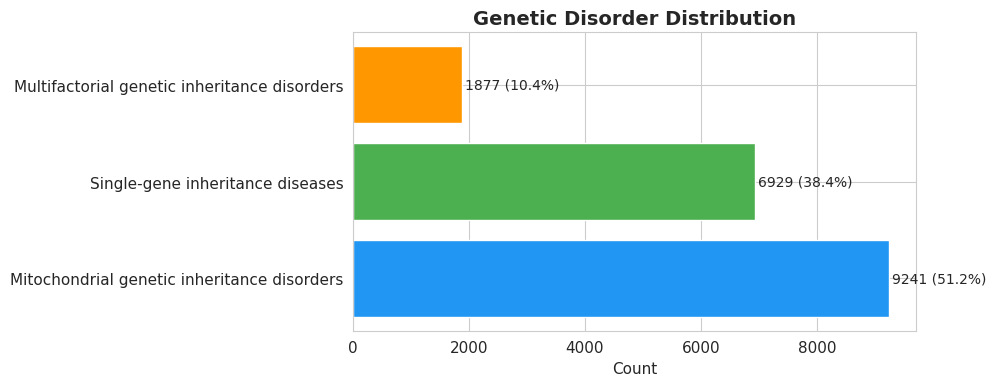

In [83]:
fig, ax = plt.subplots(figsize=(10, 4))
 
disorder_counts = plot_df[GENETIC_DISORDER_COL_NAME].value_counts()
colors_3 = ['#2196F3', '#4CAF50', '#FF9800']
ax.barh(disorder_counts.index, disorder_counts.values, color=colors_3)
ax.set_title('Genetic Disorder Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
for i, (val, count) in enumerate(zip(disorder_counts.index, disorder_counts.values)):
    ax.text(count + 50, i, f'{count} ({count/len(plot_df)*100:.1f}%)', va='center', fontsize=10)
 
plt.tight_layout()
plt.show()

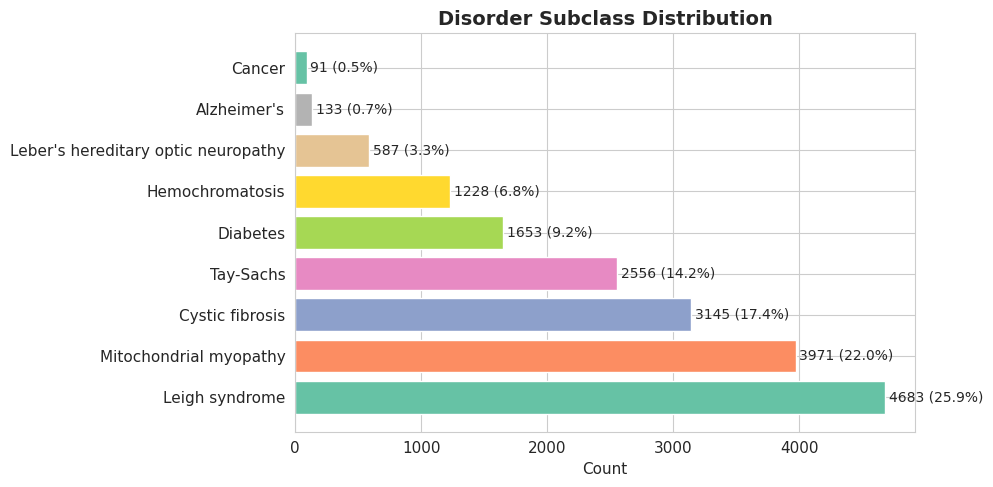

In [84]:
fig, ax = plt.subplots(figsize=(10, 5))
 
subclass_counts = plot_df[DISORDER_SUBCLASS_COL_NAME].value_counts()
colors_9 = sns.color_palette("Set2", 9)
ax.barh(subclass_counts.index, subclass_counts.values, color=colors_9)
ax.set_title('Disorder Subclass Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
for i, (val, count) in enumerate(zip(subclass_counts.index, subclass_counts.values)):
    ax.text(count + 30, i, f'{count} ({count/len(plot_df)*100:.1f}%)', va='center', fontsize=10)
 
plt.tight_layout()
plt.show()

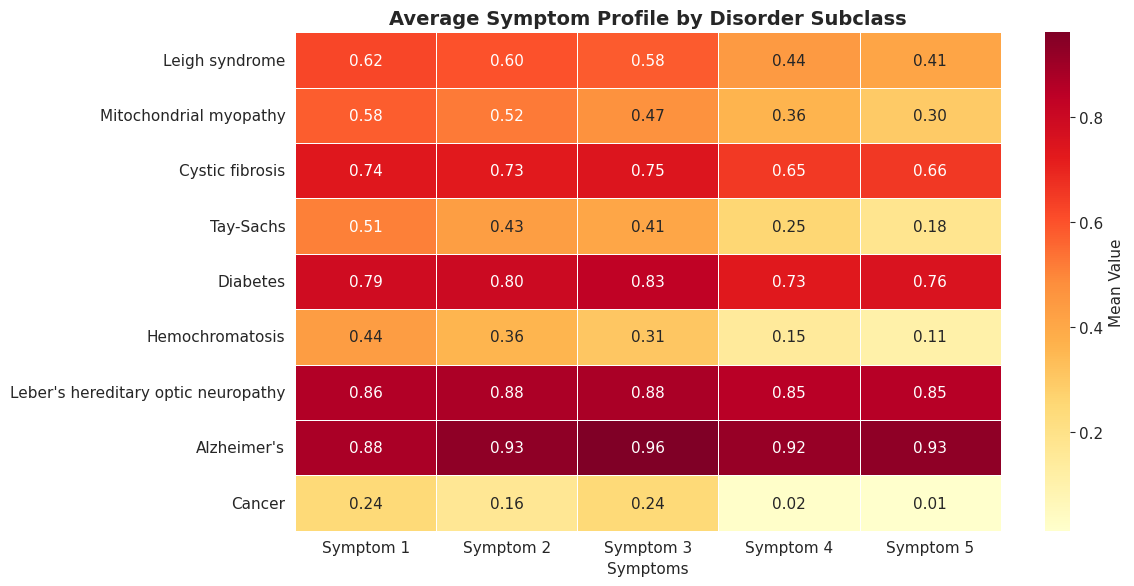

In [85]:
symptom_cols = ['Symptom 1', 'Symptom 2', 'Symptom 3', 'Symptom 4', 'Symptom 5']
symptom_cols = [c for c in symptom_cols if c in plot_df.columns]
 
symptom_means = plot_df.groupby(DISORDER_SUBCLASS_COL_NAME)[symptom_cols].mean()
symptom_means = symptom_means.loc[subclass_counts.index]
 
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(symptom_means, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean Value'})
ax.set_title('Average Symptom Profile by Disorder Subclass', fontsize=14, fontweight='bold')
ax.set_xlabel('Symptoms')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

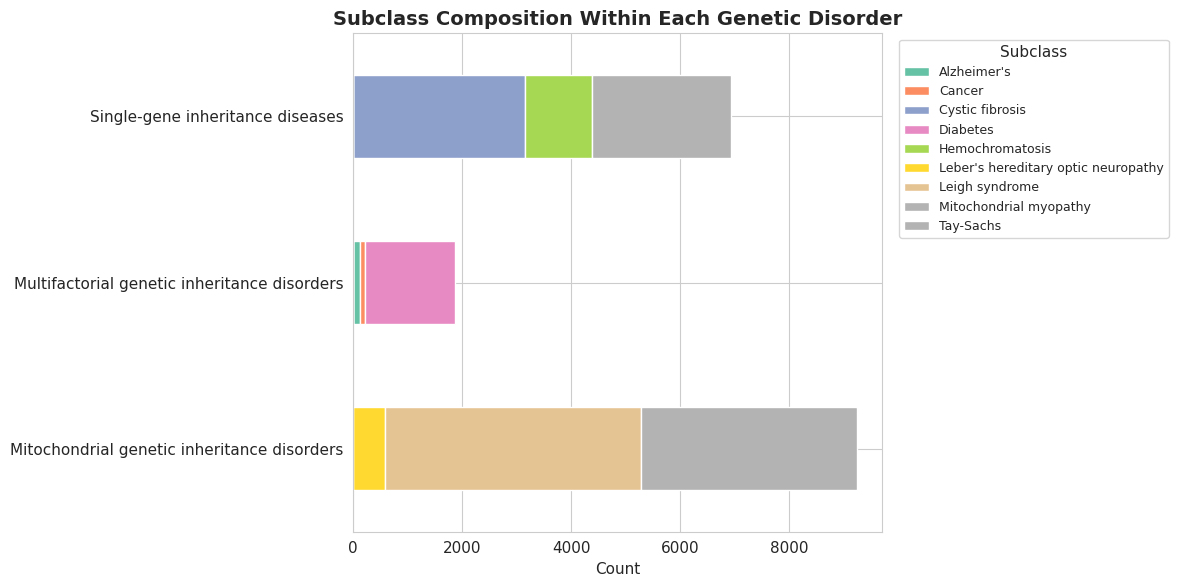

In [86]:
fig, ax = plt.subplots(figsize=(12, 6))
 
crosstab = pd.crosstab(plot_df[GENETIC_DISORDER_COL_NAME], plot_df[DISORDER_SUBCLASS_COL_NAME])
crosstab.plot(kind='barh', stacked=True, ax=ax, colormap='Set2', edgecolor='white')
ax.set_title('Subclass Composition Within Each Genetic Disorder', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
ax.set_ylabel('')
ax.legend(title='Subclass', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
 
plt.tight_layout()
plt.show()

## Phase 4: Modeling — Two Separate Tasks
* **Task 1**: Predict `Genetic Disorder` (3 classes)
* **Task 2**: Predict `Disorder Subclass` (9 classes), using predicted disorder as feature

In [87]:
# Remove Subclass column, for only predicting Disorder
df_f1 = train_df.drop(columns=[DISORDER_SUBCLASS_COL_NAME]).copy()
df_f1 = df_f1.sample(frac=1, random_state=SEED).reset_index(drop=True)
 
y_f1_full = df_f1.pop(GENETIC_DISORDER_COL_NAME)
f1_le = skp.LabelEncoder()
y_f1_full = f1_le.fit_transform(y_f1_full)
X_f1_full = df_f1
 
print(f"Task 1 - Disorder classes: {f1_le.classes_}")
print(f"X_f1: {X_f1_full.shape}")

Task 1 - Disorder classes: ['Mitochondrial genetic inheritance disorders'
 'Multifactorial genetic inheritance disorders'
 'Single-gene inheritance diseases']
X_f1: (18047, 34)


In [88]:
# keeping Disorder as a FEATURE, for predicting Subclass
df_f2 = train_df.copy()
df_f2 = df_f2.sample(frac=1, random_state=SEED).reset_index(drop=True)

gdle = skp.LabelEncoder()
df_f2[GENETIC_DISORDER_COL_NAME] = gdle.fit_transform(df_f2[GENETIC_DISORDER_COL_NAME])
 
y_f2_full = df_f2.pop(DISORDER_SUBCLASS_COL_NAME)
f2_le = skp.LabelEncoder()
y_f2_full = f2_le.fit_transform(y_f2_full)
X_f2_full = df_f2
 
print(f"Task 2 - Subclass classes: {f2_le.classes_}")
print(f"X_f2: {X_f2_full.shape}")

Task 2 - Subclass classes: ["Alzheimer's" 'Cancer' 'Cystic fibrosis' 'Diabetes' 'Hemochromatosis'
 "Leber's hereditary optic neuropathy" 'Leigh syndrome'
 'Mitochondrial myopathy' 'Tay-Sachs']
X_f2: (18047, 35)


In [89]:
X_f1_train, X_f1_test, y_f1_train, y_f1_test = skms.train_test_split(
    X_f1_full, y_f1_full, train_size=0.8, random_state=SEED
)
X_f2_train, X_f2_test, y_f2_train, y_f2_test = skms.train_test_split(
    X_f2_full, y_f2_full, train_size=0.8, random_state=SEED
)
 
X_f1_train.reset_index(drop=True, inplace=True)
X_f1_test.reset_index(drop=True, inplace=True)
X_f2_train.reset_index(drop=True, inplace=True)
X_f2_test.reset_index(drop=True, inplace=True)
 
print(f"F1 train: {X_f1_train.shape}, F1 test: {X_f1_test.shape}")
print(f"F2 train: {X_f2_train.shape}, F2 test: {X_f2_test.shape}")

F1 train: (14437, 34), F1 test: (3610, 34)
F2 train: (14437, 35), F2 test: (3610, 35)


In [90]:
class_weights_f1 = sku.class_weight.compute_class_weight(
    class_weight='balanced', classes=np.unique(y_f1_train), y=y_f1_train
)
class_weights_f1 = dict(enumerate(class_weights_f1))
 
class_weights_f2 = sku.class_weight.compute_class_weight(
    class_weight='balanced', classes=np.unique(y_f2_train), y=y_f2_train
)
class_weights_f2 = dict(enumerate(class_weights_f2))
 
sample_weights_f1 = sku.class_weight.compute_sample_weight('balanced', y_f1_train)
sample_weights_f2 = sku.class_weight.compute_sample_weight('balanced', y_f2_train)
 
print("F1 weights:", class_weights_f1)
print("F2 weights:", class_weights_f2)

F1 weights: {0: np.float64(0.654650160975831), 1: np.float64(3.210362463864799), 2: np.float64(0.8613447884971064)}
F2 weights: {0: np.float64(14.852880658436215), 1: np.float64(21.677177177177178), 2: np.float64(0.6370576295119583), 3: np.float64(1.2180038808740403), 4: np.float64(1.6435564663023678), 5: np.float64(3.517787524366472), 6: np.float64(0.42685234462775706), 7: np.float64(0.5113519640137428), 8: np.float64(0.7664171577215055)}


In [91]:
# helper function
def printScore(y_true, y_pred, label=""):
    f1 = skm.f1_score(y_true, y_pred, average="macro")
    acc = skm.accuracy_score(y_true, y_pred)
    print(f"  {label} — Acc: {acc:.4f}, F1-Macro: {f1:.4f}")

### Training Task 1 Models (Disorder Class)

**CatBoost** for **Task 1**

In [92]:
cat_model_f1 = cb.CatBoostClassifier(
    verbose=0, iterations=70, class_weights=class_weights_f1, random_seed=SEED
)
cat_model_f1.fit(X_f1_train, y_f1_train, eval_set=(X_f1_test, y_f1_test))
printScore(y_f1_train, cat_model_f1.predict(X_f1_train), "CatBoost F1 train")
printScore(y_f1_test, cat_model_f1.predict(X_f1_test), "CatBoost F1 test")

  CatBoost F1 train — Acc: 0.5836, F1-Macro: 0.5440
  CatBoost F1 test — Acc: 0.5684, F1-Macro: 0.5273


**Random Forest** for **Task 1**

In [93]:
rf_model_f1 = ske.RandomForestClassifier(
    random_state=SEED, n_jobs=-1, class_weight='balanced_subsample',
    n_estimators=100, max_depth=10, min_samples_split=5, min_samples_leaf=3
)
rf_model_f1.fit(X_f1_train, y_f1_train)
printScore(y_f1_train, rf_model_f1.predict(X_f1_train), "RF F1 train")
printScore(y_f1_test, rf_model_f1.predict(X_f1_test), "RF F1 test")

  RF F1 train — Acc: 0.7781, F1-Macro: 0.7360
  RF F1 test — Acc: 0.5820, F1-Macro: 0.5300


**XGBoost** for **Task 1**

In [94]:
xgb_model_f1 = xg.XGBClassifier(
    objective='multi:softprob', random_state=SEED, n_jobs=-1,
    learning_rate=0.0001, subsample=0.5, n_estimators=100, max_depth=8
)
xgb_model_f1.fit(X_f1_train, y_f1_train, sample_weight=sample_weights_f1)
printScore(y_f1_train, xgb_model_f1.predict(X_f1_train), "XGB F1 train")
printScore(y_f1_test, xgb_model_f1.predict(X_f1_test), "XGB F1 test")

  XGB F1 train — Acc: 0.6457, F1-Macro: 0.6081
  XGB F1 test — Acc: 0.5693, F1-Macro: 0.5275


**LightGBM** for **Task 1**

In [95]:
lgb_model_f1 = lgb.LGBMClassifier(
    objective='multiclass', random_state=SEED, n_jobs=-1,
    class_weight=class_weights_f1, learning_rate=0.1, n_estimators=70, verbose=-1
)
lgb_model_f1.fit(X_f1_train, y_f1_train)
printScore(y_f1_train, lgb_model_f1.predict(X_f1_train), "LGB F1 train")
printScore(y_f1_test, lgb_model_f1.predict(X_f1_test), "LGB F1 test")

  LGB F1 train — Acc: 0.6704, F1-Macro: 0.6359
  LGB F1 test — Acc: 0.5615, F1-Macro: 0.5252


### Training Task 2 Models

**CatBoost** for **Task 2**

In [96]:
cat_model_f2 = cb.CatBoostClassifier(
    verbose=0, iterations=80, class_weights=class_weights_f2, random_seed=SEED
)
cat_model_f2.fit(X_f2_train, y_f2_train, eval_set=(X_f2_test, y_f2_test))
printScore(y_f2_train, cat_model_f2.predict(X_f2_train), "CatBoost F2 train")
printScore(y_f2_test, cat_model_f2.predict(X_f2_test), "CatBoost F2 test")

  CatBoost F2 train — Acc: 0.7455, F1-Macro: 0.7663
  CatBoost F2 test — Acc: 0.6873, F1-Macro: 0.6890


**RandomForest** for **Task 2**

In [97]:
rf_model_f2 = ske.RandomForestClassifier(
    random_state=SEED, n_jobs=-1, class_weight='balanced_subsample',
    n_estimators=300, max_depth=10, min_samples_split=10, min_samples_leaf=5
)
rf_model_f2.fit(X_f2_train, y_f2_train)
printScore(y_f2_train, rf_model_f2.predict(X_f2_train), "RF F2 train")
printScore(y_f2_test, rf_model_f2.predict(X_f2_test), "RF F2 test")

  RF F2 train — Acc: 0.8674, F1-Macro: 0.8854
  RF F2 test — Acc: 0.6895, F1-Macro: 0.7029


**XGBoost** for **Task 2**

In [98]:
xgb_model_f2 = xg.XGBClassifier(
    objective='multi:softprob', random_state=SEED, n_jobs=-1,
    learning_rate=0.15, subsample=1, n_estimators=100, max_depth=5
)
xgb_model_f2.fit(X_f2_train, y_f2_train, sample_weight=sample_weights_f2)
printScore(y_f2_train, xgb_model_f2.predict(X_f2_train), "XGB F2 train")
printScore(y_f2_test, xgb_model_f2.predict(X_f2_test), "XGB F2 test")

  XGB F2 train — Acc: 0.8257, F1-Macro: 0.8566
  XGB F2 test — Acc: 0.6889, F1-Macro: 0.7000


**LightGBM** for **Task 2**

In [99]:
lgb_model_f2 = lgb.LGBMClassifier(
    objective='multiclass', random_state=SEED, n_jobs=-1,
    learning_rate=0.08, n_estimators=100, verbose=-1
)
lgb_model_f2.fit(X_f2_train, y_f2_train)
printScore(y_f2_train, lgb_model_f2.predict(X_f2_train), "LGB F2 train")
printScore(y_f2_test, lgb_model_f2.predict(X_f2_test), "LGB F2 test")

  LGB F2 train — Acc: 0.9343, F1-Macro: 0.9628
  LGB F2 test — Acc: 0.7033, F1-Macro: 0.6878


### Ensemble via Majority Voting

In [100]:
class MixModel(skb.BaseEstimator):
    def __init__(self, algs):
        self.algs = algs

    def fit(self, X, y):
        for alg in self.algs:
            alg.fit(X, y)
        self.algs_ = self.algs
        return self

    def predict(self, X):
        predictions = np.column_stack([m.predict(X) for m in self.algs_])
        return np.apply_along_axis(lambda x: np.bincount(x.astype(int)).argmax(), axis=1, arr=predictions)

In [101]:
mixed_f1 = MixModel(algs=[cat_model_f1, rf_model_f1, xgb_model_f1, lgb_model_f1])
mixed_f1.fit(X_f1_train, y_f1_train)
printScore(y_f1_train, mixed_f1.predict(X_f1_train), "Ensemble F1 train")
printScore(y_f1_test, mixed_f1.predict(X_f1_test), "Ensemble F1 test")

  Ensemble F1 train — Acc: 0.7110, F1-Macro: 0.6646
  Ensemble F1 test — Acc: 0.5875, F1-Macro: 0.5205


In [102]:
mixed_f2 = MixModel(algs=[rf_model_f2])
mixed_f2.fit(X_f2_train, y_f2_train)
printScore(y_f2_train, mixed_f2.predict(X_f2_train), "Ensemble F2 train")
printScore(y_f2_test, mixed_f2.predict(X_f2_test), "Ensemble F2 test")

  Ensemble F2 train — Acc: 0.8674, F1-Macro: 0.8854
  Ensemble F2 test — Acc: 0.6895, F1-Macro: 0.7029


## Saving the Model

In [103]:
# Task 1 (Disorder) — final ensemble trained on full data
final_f1 = MixModel(algs=[cat_model_f1, rf_model_f1, xgb_model_f1, lgb_model_f1])
final_f1.fit(X_f1_full, y_f1_full)
print("✓ Final Task 1 trained on full data")
 
# Task 2 (Subclass) — using RF alone based on earlier results
final_f2 = MixModel(algs=[rf_model_f2])
final_f2.fit(X_f2_full, y_f2_full)
print("✓ Final Task 2 trained on full data")

✓ Final Task 1 trained on full data
✓ Final Task 2 trained on full data


In [104]:
import os
import joblib

# 1. Define the absolute Kaggle working path
artifact_dir = '/kaggle/working/artifacts'
os.makedirs(artifact_dir, exist_ok=True)

# 2. Save using the explicit directory variable
joblib.dump(final_f1, f'{artifact_dir}/model_f1.pkl')
joblib.dump(final_f2, f'{artifact_dir}/model_f2.pkl')

joblib.dump(f1_le, f'{artifact_dir}/f1_le.pkl')
joblib.dump(f2_le, f'{artifact_dir}/f2_le.pkl')
joblib.dump(gdle, f'{artifact_dir}/gdle.pkl')

# Save feature columns (so server knows what features to expect)
feature_columns_f1 = list(X_f1_full.columns)
feature_columns_f2 = list(X_f2_full.columns)
joblib.dump(feature_columns_f1, 'artifacts/feature_columns_f1.pkl')
joblib.dump(feature_columns_f2, 'artifacts/feature_columns_f2.pkl')

['artifacts/feature_columns_f2.pkl']

In [105]:
preprocessing_info = {
    'categorical_fills': {
        'Assisted conception IVF/ART': 'Yes',
        'H/O radiation exposure (x-ray)': '-',
        'Respiratory Rate (breaths/min)': 'Normal (30-60)',
        'Folic acid details (peri-conceptional)': 'Yes',
        'H/O serious maternal illness': 'No',
        'Birth asphyxia': 'Not available',
        'Birth defects': 'Singular',
        'Blood test result': 'inconclusive',
        'H/O substance abuse': '-',
        'History of anomalies in previous pregnancies': 'No',
        'Inherited from father': 'No',
        'Gender': 'Ambiguous',
        'Follow-up': 'Low',
        'Maternal gene': 'No',
    },
    'wbc_mean': float(wbc_mean),
    'age_mean': float(age_mean),
    'custom_feat': custom_feat,
    'cols_to_drop': [
        'Patient First Name', 'Family Name', "Father's name",
        "Father's age", "Mother's age",
        'Institute Name', 'Location of Institute',
        'Status', 'Parental consent',
        'Autopsy shows birth defect (if applicable)',
        'Place of birth', 'No. of previous abortion'
    ]
}
joblib.dump(preprocessing_info, f'{artifact_dir}/preprocessing_info.pkl')

mode_fills = {}
for col in ['Symptom 1', 'Symptom 2', 'Symptom 3', 'Symptom 4', 'Symptom 5', 'Heart Rate (rates/min']:
    if col in train_df.columns or col in preprocessing_info['custom_feat']:
        # We need to recompute from raw train data — use a sensible default
        pass
 
print("✓ All artifacts saved to /artifacts folder")
print("Files saved:")
for f in os.listdir('artifacts'):
    print(f"  {f}")

✓ All artifacts saved to /artifacts folder
Files saved:
  f1_le.pkl
  f2_le.pkl
  feature_columns_f1.pkl
  preprocessing_info.pkl
  feature_columns_f2.pkl
  gdle.pkl
  model_f1.pkl
  model_f2.pkl


In [106]:
import shutil
shutil.make_archive('artifacts', 'zip', 'artifacts')
print("✓ Created artifacts.zip")

✓ Created artifacts.zip
